<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/heat_exchanger_condition_monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Condition-based monitoring of a gas cooler with NeqSim

This tutorial builds a thermodynamics-aware monitoring workflow for a two-stream natural-gas
cooler. It estimates effective conductance from operating data, separates true thermal
degradation from changing process conditions, checks measurement consistency, and recommends
when inspection or cleaning should be considered.

**Intended audience:** process, operations, maintenance, and digital-twin engineers.

**Prerequisites:** heat and energy balances, basic Python, and introductory NeqSim process
simulation.

## Learning objectives

After completing the notebook, you can:

1. build hot-gas and cooling-water streams with appropriate NeqSim property models;
2. connect them through the native two-stream `HeatExchanger`;
3. validate heat duty, effectiveness, temperature approach, and energy closure;
4. infer effective $UA$ from changing operating data;
5. screen fouling resistance and measurement quality separately;
6. classify equipment health and reuse the workflow for new historian records.

## Engineering context and monitoring question

An outlet-temperature trend alone is ambiguous. A warmer gas outlet can result from fouling,
less cooling water, higher gas throughput, or a biased sensor. The monitoring question is:

> Has exchanger thermal conductance degraded after accounting for measured boundary conditions?

The tutorial uses deterministic synthetic historian data so every result is reproducible.
No plant data, proprietary geometry, or maintenance decision rule is implied.

## Theory: energy balance and conductance

At steady state, with negligible heat loss, the hot-side and cold-side duties have equal
magnitude:

$$
\dot Q = \dot H_{h,in} - \dot H_{h,out} = \dot H_{c,out} - \dot H_{c,in}
$$

The temperature driving force for counter-current flow is the log-mean temperature difference:

$$
\Delta T_{lm} = \frac{\Delta T_1 - \Delta T_2}{\ln(\Delta T_1 / \Delta T_2)}
$$

The effective conductance is $UA = \dot Q / \Delta T_{lm}$, where $U$ is the overall
heat-transfer coefficient in W/(m² K) and $A$ is area in m². In this notebook NeqSim solves
the coupled enthalpy balance for a specified $UA$; monitoring inverts that calculation.

## Theory: normalized health and fouling resistance

A clean reference removes the equipment scale from the health indicator:

$$
H_{UA} = \frac{UA_{observed}}{UA_{clean}}
$$

For fixed surface area $A$, the added area-specific thermal resistance is estimated as:

$$
R_f = A\left(\frac{1}{UA_{observed}} - \frac{1}{UA_{clean}}\right)
$$

Here $R_f$ is reported in m² K/W. This is an effective resistance: it also absorbs model
mismatch, maldistribution, bypassing, and unmeasured operating effects.

## Assumptions, units, and validity limits

- Pressures are absolute (`bara`); temperatures are in °C; mass flow is kg/h.
- The hot stream is a dry synthetic natural gas represented by SRK with classic mixing.
- Cooling water is represented by SRK-CPA, which is preferable to a cubic model for water.
- Each historian point is treated as a converged steady state.
- Pressure drop, ambient heat loss, wall storage, and flow maldistribution are excluded.
- The exchanger area is assumed only to express an effective fouling resistance.
- Thresholds are illustrative screening criteria, not inspection or integrity requirements.

## 1. Clean Colab setup

The setup installs the current public PyPI package only when NeqSim is absent. The notebook has
no dependency on the validation runner's wheel snapshot.

In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )

neqsim_version = importlib.metadata.version("neqsim")
print(f"NeqSim version: {neqsim_version}")

NeqSim version: 3.16.0


## 2. Imports and deterministic design basis

The Java-backed classes are taken from the released NeqSim package. A fixed composition and
fixed pressures isolate thermal performance while measured inlet conditions and flows vary.

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim


SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger

GAS_COMPOSITION = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.90,
    "ethane": 0.05,
    "propane": 0.02,
}
GAS_PRESSURE_BARA = 80.0
WATER_PRESSURE_BARA = 5.0
CLEAN_UA_W_K = 50_000.0
EXCHANGER_AREA_M2 = 120.0

## 3. Build NeqSim inlet streams

Each call creates independent fluids and streams. This avoids hidden state during scenario
sweeps and makes the function safe to reuse for one historian row at a time.

In [3]:
def build_input_streams(
    gas_flow_kg_h,
    water_flow_kg_h,
    gas_inlet_c,
    water_inlet_c,
):
    gas = SystemSrkEos(gas_inlet_c + 273.15, GAS_PRESSURE_BARA)
    for component, mole_fraction in GAS_COMPOSITION.items():
        gas.addComponent(component, mole_fraction)
    gas.createDatabase(True)
    gas.setMixingRule("classic")
    gas.setMultiPhaseCheck(True)
    gas.setTotalFlowRate(gas_flow_kg_h, "kg/hr")

    hot_stream = Stream("hot natural gas", gas)
    hot_stream.run()

    water = SystemSrkCPAstatoil(water_inlet_c + 273.15, WATER_PRESSURE_BARA)
    water.addComponent("water", 1.0)
    water.createDatabase(True)
    water.setMixingRule(10)
    water.setMultiPhaseCheck(True)
    water.setTotalFlowRate(water_flow_kg_h, "kg/hr")

    cold_stream = Stream("cooling water", water)
    cold_stream.run()
    return hot_stream, cold_stream

## 4. Reusable native exchanger calculation

`HeatExchanger` connects both streams, applies counter-current flow, and solves outlet states for
the supplied conductance. Enthalpy differences provide an independent duty and balance audit.

In [4]:
def run_exchanger_case(
    ua_w_k,
    gas_flow_kg_h=50_000.0,
    water_flow_kg_h=100_000.0,
    gas_inlet_c=95.0,
    water_inlet_c=15.0,
):
    hot_in, cold_in = build_input_streams(
        gas_flow_kg_h,
        water_flow_kg_h,
        gas_inlet_c,
        water_inlet_c,
    )
    exchanger = HeatExchanger(
        "E-201 monitored gas cooler",
        hot_in,
        cold_in,
    )
    exchanger.setFlowArrangement("counterflow")
    exchanger.setUAvalue(ua_w_k)
    exchanger.setGuessOutTemperature(40.0, "C")
    exchanger.run()

    hot_out = exchanger.getOutStream(0)
    cold_out = exchanger.getOutStream(1)
    hot_duty_w = (
        hot_in.getFluid().getEnthalpy()
        - hot_out.getFluid().getEnthalpy()
    )
    cold_duty_w = (
        cold_out.getFluid().getEnthalpy()
        - cold_in.getFluid().getEnthalpy()
    )
    average_duty_w = 0.5 * (hot_duty_w + cold_duty_w)
    relative_residual = abs(hot_duty_w - cold_duty_w) / average_duty_w

    return {
        "ua_w_k": ua_w_k,
        "hot_in_c": hot_in.getTemperature("C"),
        "hot_out_c": hot_out.getTemperature("C"),
        "cold_in_c": cold_in.getTemperature("C"),
        "cold_out_c": cold_out.getTemperature("C"),
        "hot_duty_w": hot_duty_w,
        "cold_duty_w": cold_duty_w,
        "energy_residual_fraction": relative_residual,
        "effectiveness": exchanger.getThermalEffectiveness(),
        "minimum_approach_c": min(
            hot_in.getTemperature("C") - cold_out.getTemperature("C"),
            hot_out.getTemperature("C") - cold_in.getTemperature("C"),
        ),
        "objects": {
            "hot_in": hot_in,
            "hot_out": hot_out,
            "cold_in": cold_in,
            "cold_out": cold_out,
            "exchanger": exchanger,
        },
    }

## 5. Base-case calculation and stream table

The clean base case establishes the reference duty, outlet temperatures, effectiveness, and
minimum terminal approach used later in the monitoring limits.

In [5]:
base_case = run_exchanger_case(CLEAN_UA_W_K)

base_table = pd.DataFrame(
    [
        {
            "Stream": "hot gas inlet",
            "Temperature (°C)": base_case["hot_in_c"],
            "Pressure (bara)": GAS_PRESSURE_BARA,
            "Flow (kg/h)": 50_000.0,
        },
        {
            "Stream": "hot gas outlet",
            "Temperature (°C)": base_case["hot_out_c"],
            "Pressure (bara)": GAS_PRESSURE_BARA,
            "Flow (kg/h)": 50_000.0,
        },
        {
            "Stream": "cooling water inlet",
            "Temperature (°C)": base_case["cold_in_c"],
            "Pressure (bara)": WATER_PRESSURE_BARA,
            "Flow (kg/h)": 100_000.0,
        },
        {
            "Stream": "cooling water outlet",
            "Temperature (°C)": base_case["cold_out_c"],
            "Pressure (bara)": WATER_PRESSURE_BARA,
            "Flow (kg/h)": 100_000.0,
        },
    ]
)
display(base_table.round(4))

print(f"Transferred duty: {base_case['hot_duty_w'] / 1e6:.4f} MW")
print(f"Thermal effectiveness: {base_case['effectiveness']:.4f}")
print(f"Minimum terminal approach: {base_case['minimum_approach_c']:.4f} °C")

Transferred duty: 2.0290 MW
Thermal effectiveness: 0.6827
Minimum terminal approach: 24.5326 °C


,Stream,Temperature (°C),Pressure (bara),Flow (kg/h)
0,hot gas inlet,95.0000,80.0,50000.0
1,hot gas outlet,39.5326,80.0,50000.0
2,cooling water inlet,15.0000,5.0,100000.0
3,cooling water outlet,35.0083,5.0,100000.0


The gas cools without phase change and the water warms. The two enthalpy-based duties should
close to numerical precision; a plant data set will normally have a much larger residual because
of sensor uncertainty, heat loss, and unmeasured flows.

In [6]:
base_checks = {
    "hot stream cools": base_case["hot_out_c"] < base_case["hot_in_c"],
    "cold stream warms": base_case["cold_out_c"] > base_case["cold_in_c"],
    "positive duty": base_case["hot_duty_w"] > 0.0,
    "positive approach": base_case["minimum_approach_c"] > 0.0,
    "energy closure below 1e-7": (
        base_case["energy_residual_fraction"] < 1.0e-7
    ),
    "bounded effectiveness": 0.0 < base_case["effectiveness"] < 1.0,
}

display(pd.Series(base_checks, name="Passed").to_frame())
assert all(base_checks.values())

,Passed
hot stream cools,True
cold stream warms,True
positive duty,True
positive approach,True
energy closure below 1e-7,True
bounded effectiveness,True


## 6. Monitoring workflow overview

The process model normalizes each measurement to its actual inlet temperatures and flow rates.
The diagnostic layer rejects inconsistent data before treating low inferred conductance as
fouling.

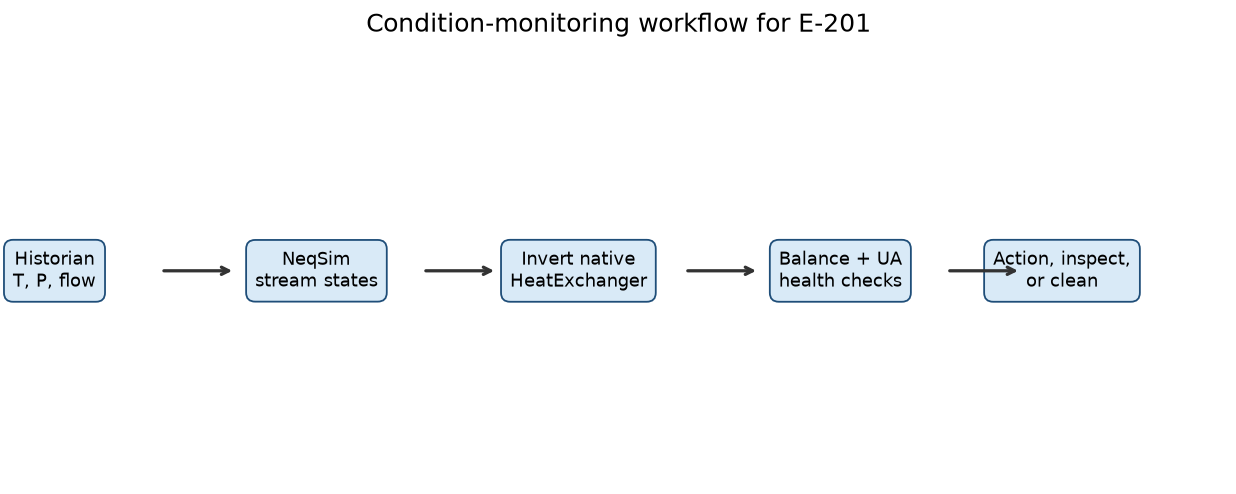

In [7]:
figure, axis = plt.subplots(figsize=(12.0, 4.2))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

boxes = [
    (0.4, "Historian\nT, P, flow"),
    (3.0, "NeqSim\nstream states"),
    (5.6, "Invert native\nHeatExchanger"),
    (8.2, "Balance + UA\nhealth checks"),
    (10.4, "Action, inspect,\nor clean"),
]

for x_position, label in boxes:
    axis.text(
        x_position,
        2.0,
        label,
        ha="center",
        va="center",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.5",
            "facecolor": "#D9EAF7",
            "edgecolor": "#1F4E79",
        },
    )

for start_x in (1.45, 4.05, 6.65, 9.25):
    axis.annotate(
        "",
        xy=(start_x + 0.75, 2.0),
        xytext=(start_x, 2.0),
        arrowprops={"arrowstyle": "->", "color": "#333333", "lw": 1.8},
    )

axis.set_title(
    "Condition-monitoring workflow for E-201",
    fontsize=14,
    pad=16,
)
plt.show()

## 7. Create a reproducible operating history

The underlying exchanger gradually fouls, is cleaned after day 15, and then begins a new slower
degradation cycle. Gas load, water flow, and both inlet temperatures vary independently.

In [8]:
day_values = np.arange(24, dtype=float)
true_ua_values_w_k = np.where(
    day_values <= 15.0,
    CLEAN_UA_W_K - 800.0 * day_values,
    48_000.0 - 500.0 * (day_values - 16.0),
)

historian_inputs = pd.DataFrame(
    {
        "day": day_values,
        "gas_flow_kg_h": 50_000.0 * (
            1.0 + 0.10 * np.sin(0.55 * day_values)
        ),
        "water_flow_kg_h": 100_000.0 * (
            1.0 + 0.08 * np.cos(0.41 * day_values)
        ),
        "gas_inlet_c": 95.0 + 3.5 * np.sin(0.31 * day_values),
        "water_inlet_c": 15.0 + 2.5 * np.cos(0.27 * day_values),
        "true_ua_w_k": true_ua_values_w_k,
    }
)

display(historian_inputs.head().round(4))

,day,gas_flow_kg_h,water_flow_kg_h,gas_inlet_c,water_inlet_c,true_ua_w_k
0,0.0,50000.0000,108000.0000,95.0000,17.5000,50000.0
1,1.0,52613.4361,107336.9666,96.0677,17.4094,49200.0
2,2.0,54456.0368,105457.7697,97.0336,17.1443,48400.0
3,3.0,54984.3251,102673.9018,97.8057,16.7237,47600.0
4,4.0,54042.4820,99446.8124,98.3102,16.1783,46800.0


## 8. Generate measured outlet temperatures

NeqSim supplies the physically consistent underlying outlet states. Small deterministic
temperature errors emulate normal instrument uncertainty. One larger hot-outlet bias is inserted
on day 10 to test the data-quality gate.

In [9]:
true_rows = []

for row in historian_inputs.itertuples(index=False):
    result = run_exchanger_case(
        ua_w_k=row.true_ua_w_k,
        gas_flow_kg_h=row.gas_flow_kg_h,
        water_flow_kg_h=row.water_flow_kg_h,
        gas_inlet_c=row.gas_inlet_c,
        water_inlet_c=row.water_inlet_c,
    )
    true_rows.append(
        {
            "true_hot_out_c": result["hot_out_c"],
            "true_cold_out_c": result["cold_out_c"],
            "true_duty_mw": result["hot_duty_w"] / 1.0e6,
        }
    )

historian = pd.concat(
    [
        historian_inputs,
        pd.DataFrame(true_rows),
    ],
    axis=1,
)
historian["measured_hot_out_c"] = (
    historian["true_hot_out_c"]
    + 0.10 * np.sin(1.3 * historian["day"])
)
historian["measured_cold_out_c"] = (
    historian["true_cold_out_c"]
    + 0.08 * np.cos(1.1 * historian["day"])
)
historian.loc[historian["day"] == 10.0, "measured_hot_out_c"] += 2.2

display(historian.head(8).round(5))

,day,gas_flow_kg_h,water_flow_kg_h,gas_inlet_c,water_inlet_c,true_ua_w_k,true_hot_out_c,true_cold_out_c,true_duty_mw,measured_hot_out_c,measured_cold_out_c
0,0.0,50000.00000,108000.00000,95.00000,17.50000,50000.0,40.93821,35.49667,1.97647,40.93821,35.57667
1,1.0,52613.43614,107336.96658,96.06771,17.40943,49200.0,43.15220,36.03422,2.03369,43.24856,36.07051
2,2.0,54456.03680,105457.76966,97.03362,17.14427,48400.0,44.84083,36.48052,2.07472,44.89238,36.43344
3,3.0,54984.32514,102673.90182,97.80567,16.72375,47600.0,45.69151,36.74280,2.09095,45.62273,36.66380
4,4.0,54042.48202,99446.81241,98.31024,16.17832,46800.0,45.57562,36.74505,2.07960,45.48728,36.72046
5,5.0,51908.30496,96311.41847,98.49924,15.54752,46000.0,44.57078,36.43152,2.04334,44.59230,36.48822
6,6.0,49211.27153,93787.43773,98.35465,14.87704,45200.0,42.97870,35.79127,1.99030,43.07856,35.86729
7,7.0,46746.87431,92293.24109,97.89025,14.21547,44400.0,41.30256,34.88898,1.93329,41.33447,34.90125


## 9. Measurement energy-balance audit

Measured outlet temperatures are converted back to enthalpy with the same NeqSim property
packages. The relative hot/cold duty mismatch is a data-quality indicator, not silently absorbed
into the fouling estimate.

In [10]:
def outlet_enthalpy_duties(
    gas_flow_kg_h,
    water_flow_kg_h,
    gas_inlet_c,
    water_inlet_c,
    measured_hot_out_c,
    measured_cold_out_c,
):
    hot_in, cold_in = build_input_streams(
        gas_flow_kg_h,
        water_flow_kg_h,
        gas_inlet_c,
        water_inlet_c,
    )
    hot_out_fluid = hot_in.getFluid().clone()
    hot_out_fluid.setTemperature(measured_hot_out_c, "C")
    ThermodynamicOperations(hot_out_fluid).TPflash()
    hot_out_fluid.initProperties()

    cold_out_fluid = cold_in.getFluid().clone()
    cold_out_fluid.setTemperature(measured_cold_out_c, "C")
    ThermodynamicOperations(cold_out_fluid).TPflash()
    cold_out_fluid.initProperties()

    hot_duty_w = (
        hot_in.getFluid().getEnthalpy()
        - hot_out_fluid.getEnthalpy()
    )
    cold_duty_w = (
        cold_out_fluid.getEnthalpy()
        - cold_in.getFluid().getEnthalpy()
    )
    average_absolute_duty_w = 0.5 * (
        abs(hot_duty_w) + abs(cold_duty_w)
    )
    imbalance_percent = (
        100.0
        * abs(hot_duty_w - cold_duty_w)
        / average_absolute_duty_w
    )
    return hot_duty_w, cold_duty_w, imbalance_percent


duty_audits = [
    outlet_enthalpy_duties(
        row.gas_flow_kg_h,
        row.water_flow_kg_h,
        row.gas_inlet_c,
        row.water_inlet_c,
        row.measured_hot_out_c,
        row.measured_cold_out_c,
    )
    for row in historian.itertuples(index=False)
]

historian["measured_hot_duty_mw"] = [
    values[0] / 1.0e6
    for values in duty_audits
]
historian["measured_cold_duty_mw"] = [
    values[1] / 1.0e6
    for values in duty_audits
]
historian["energy_imbalance_percent"] = [
    values[2]
    for values in duty_audits
]

## 10. Invert the NeqSim exchanger to estimate effective UA

The gas outlet falls monotonically as $UA$ increases. A bounded bisection therefore finds the
conductance that reproduces the measured hot outlet under that row's actual boundary conditions.
No unpublished optimizer or hidden initial state is required.

In [11]:
def infer_ua_from_hot_outlet(
    measured_hot_out_c,
    gas_flow_kg_h,
    water_flow_kg_h,
    gas_inlet_c,
    water_inlet_c,
    lower_ua_w_k=10_000.0,
    upper_ua_w_k=80_000.0,
    iterations=20,
):
    def residual(ua_w_k):
        result = run_exchanger_case(
            ua_w_k=ua_w_k,
            gas_flow_kg_h=gas_flow_kg_h,
            water_flow_kg_h=water_flow_kg_h,
            gas_inlet_c=gas_inlet_c,
            water_inlet_c=water_inlet_c,
        )
        return result["hot_out_c"] - measured_hot_out_c

    lower_residual = residual(lower_ua_w_k)
    upper_residual = residual(upper_ua_w_k)
    if lower_residual * upper_residual > 0.0:
        return math.nan

    for _ in range(iterations):
        midpoint_ua_w_k = 0.5 * (lower_ua_w_k + upper_ua_w_k)
        midpoint_residual = residual(midpoint_ua_w_k)
        if lower_residual * midpoint_residual <= 0.0:
            upper_ua_w_k = midpoint_ua_w_k
        else:
            lower_ua_w_k = midpoint_ua_w_k
            lower_residual = midpoint_residual

    return 0.5 * (lower_ua_w_k + upper_ua_w_k)

In [12]:
estimated_ua_values_w_k = []

for row in historian.itertuples(index=False):
    estimated_ua_values_w_k.append(
        infer_ua_from_hot_outlet(
            measured_hot_out_c=row.measured_hot_out_c,
            gas_flow_kg_h=row.gas_flow_kg_h,
            water_flow_kg_h=row.water_flow_kg_h,
            gas_inlet_c=row.gas_inlet_c,
            water_inlet_c=row.water_inlet_c,
        )
    )

historian["estimated_ua_w_k"] = estimated_ua_values_w_k
clean_reference_ua_w_k = float(
    historian.loc[historian["day"] <= 4.0, "estimated_ua_w_k"].median()
)
historian["ua_health_fraction"] = (
    historian["estimated_ua_w_k"] / clean_reference_ua_w_k
)
historian["effective_fouling_m2_k_w"] = EXCHANGER_AREA_M2 * (
    1.0 / historian["estimated_ua_w_k"]
    - 1.0 / clean_reference_ua_w_k
)

monitoring_columns = [
    "day",
    "true_ua_w_k",
    "estimated_ua_w_k",
    "ua_health_fraction",
    "effective_fouling_m2_k_w",
    "energy_imbalance_percent",
]
display(historian[monitoring_columns].round(6))

,day,true_ua_w_k,estimated_ua_w_k,ua_health_fraction,effective_fouling_m2_k_w,energy_imbalance_percent
0,0.0,50000.0,50000.014305,1.035092,-0.000084,0.450616
1,1.0,49200.0,49016.346931,1.014728,-0.000036,0.383636
2,2.0,48400.0,48304.915428,1.000000,0.000000,0.147353
3,3.0,47600.0,47723.460197,0.987963,0.000030,0.536486
4,4.0,46800.0,46954.283714,0.972039,0.000071,0.292053
5,5.0,46000.0,45963.473320,0.951528,0.000127,0.316744
6,6.0,45200.0,45034.546852,0.932297,0.000180,0.553641
7,7.0,44400.0,44348.015785,0.918085,0.000222,0.118060
8,8.0,43600.0,43732.914925,0.905351,0.000260,0.475156
9,9.0,42800.0,42920.279503,0.888528,0.000312,0.505385


## 11. Principal result: boundary-condition-normalized conductance

The inferred $UA$ follows degradation and the cleaning reset despite changing loads and inlet
temperatures. Day 10 is intentionally inconsistent and should be rejected by the balance gate.

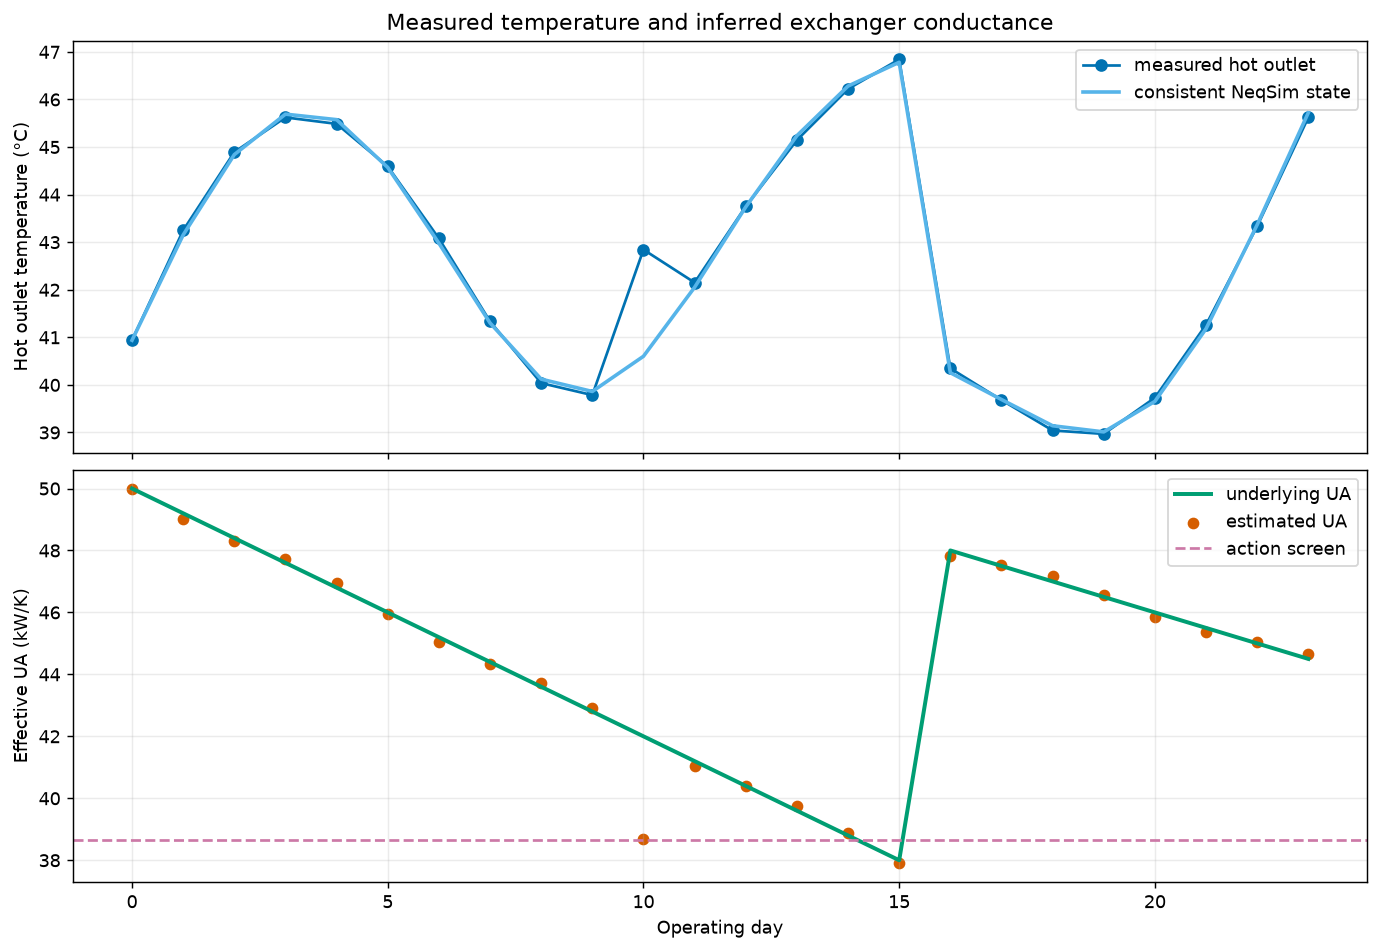

In [13]:
figure, axes = plt.subplots(
    2,
    1,
    figsize=(10.5, 7.2),
    sharex=True,
    constrained_layout=True,
)

axes[0].plot(
    historian["day"],
    historian["measured_hot_out_c"],
    marker="o",
    color="#0072B2",
    label="measured hot outlet",
)
axes[0].plot(
    historian["day"],
    historian["true_hot_out_c"],
    color="#56B4E9",
    linewidth=2.0,
    label="consistent NeqSim state",
)
axes[0].set_ylabel("Hot outlet temperature (°C)")
axes[0].set_title("Measured temperature and inferred exchanger conductance")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    historian["day"],
    historian["true_ua_w_k"] / 1000.0,
    color="#009E73",
    linewidth=2.2,
    label="underlying UA",
)
axes[1].scatter(
    historian["day"],
    historian["estimated_ua_w_k"] / 1000.0,
    color="#D55E00",
    s=30,
    label="estimated UA",
)
axes[1].axhline(
    0.80 * clean_reference_ua_w_k / 1000.0,
    color="#CC79A7",
    linestyle="--",
    label="action screen",
)
axes[1].set_xlabel("Operating day")
axes[1].set_ylabel("Effective UA (kW/K)")
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.show()

## 12. Health classification

The data-quality check has priority. Consistent records are classified as healthy, watch, or
action according to normalized conductance. This ordering prevents a biased temperature
measurement from becoming a false cleaning recommendation.

In [14]:
def classify_health(ua_health_fraction, energy_imbalance_percent):
    if energy_imbalance_percent > 3.0:
        return "data-quality alert"
    if ua_health_fraction < 0.80:
        return "action: degraded"
    if ua_health_fraction < 0.90:
        return "watch"
    return "healthy"


historian["health_state"] = [
    classify_health(health, imbalance)
    for health, imbalance in zip(
        historian["ua_health_fraction"],
        historian["energy_imbalance_percent"],
    )
]

state_summary = (
    historian.groupby("health_state", sort=False)
    .agg(
        records=("day", "count"),
        minimum_health=("ua_health_fraction", "min"),
        maximum_imbalance=("energy_imbalance_percent", "max"),
    )
    .reset_index()
)
display(state_summary.round(5))

,health_state,records,minimum_health,maximum_imbalance
0,healthy,17,0.90535,0.55364
1,watch,5,0.80511,0.59325
2,data-quality alert,1,0.80075,4.28615
3,action: degraded,1,0.78482,0.21107


## 13. Fouling-resistance and cleaning interpretation

Effective resistance increases before cleaning and falls after cleaning. Negative values near the
clean reference are possible within measurement uncertainty and should not be interpreted as
physical negative fouling.

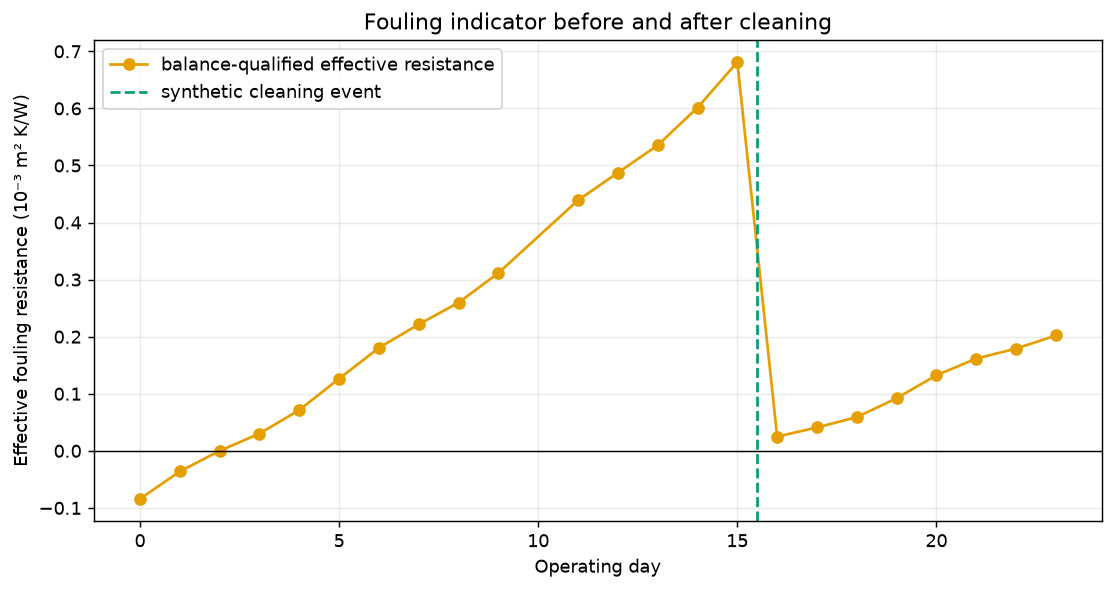

In [15]:
valid_measurements = historian["energy_imbalance_percent"] <= 3.0

figure, axis = plt.subplots(figsize=(10.0, 4.8))
axis.plot(
    historian.loc[valid_measurements, "day"],
    1000.0 * historian.loc[
        valid_measurements,
        "effective_fouling_m2_k_w",
    ],
    marker="o",
    color="#E69F00",
    label="balance-qualified effective resistance",
)
axis.axvline(
    15.5,
    color="#009E73",
    linestyle="--",
    label="synthetic cleaning event",
)
axis.axhline(0.0, color="black", linewidth=0.8)
axis.set_xlabel("Operating day")
axis.set_ylabel("Effective fouling resistance (10⁻³ m² K/W)")
axis.set_title("Fouling indicator before and after cleaning")
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## 14. Diagnostic map: degradation versus data quality

The horizontal axis represents physical thermal performance after normalization. The vertical
axis represents measurement inconsistency. Records in the upper region require instrumentation
or data reconciliation before maintenance conclusions.

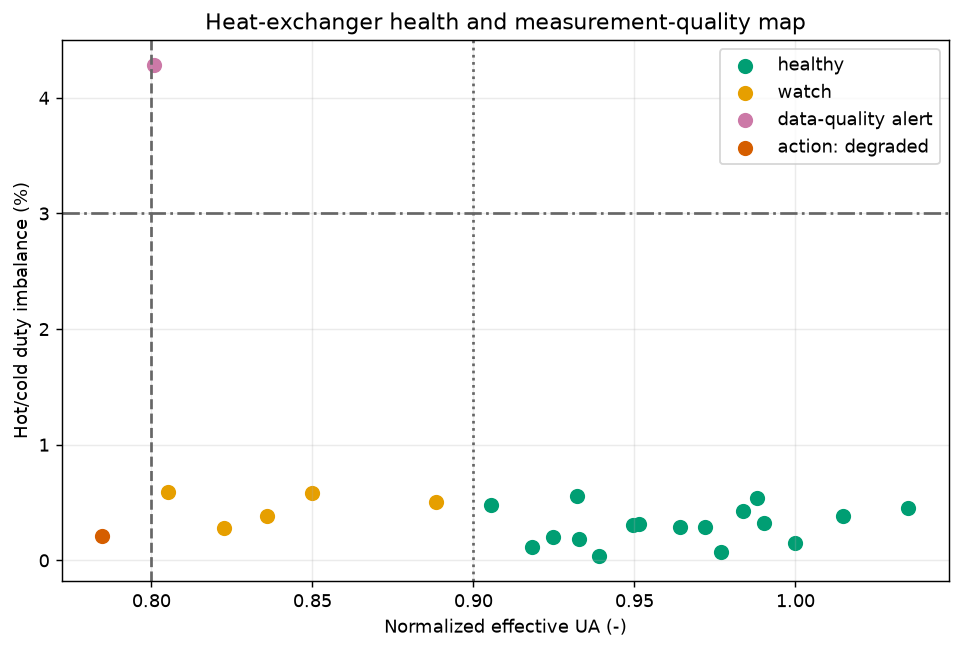

In [16]:
state_colors = {
    "healthy": "#009E73",
    "watch": "#E69F00",
    "action: degraded": "#D55E00",
    "data-quality alert": "#CC79A7",
}

figure, axis = plt.subplots(figsize=(8.8, 5.4))

for health_state, subset in historian.groupby("health_state", sort=False):
    axis.scatter(
        subset["ua_health_fraction"],
        subset["energy_imbalance_percent"],
        s=55,
        color=state_colors[health_state],
        label=health_state,
    )

axis.axvline(0.90, color="#666666", linestyle=":")
axis.axvline(0.80, color="#666666", linestyle="--")
axis.axhline(3.0, color="#666666", linestyle="-.")
axis.set_xlabel("Normalized effective UA (-)")
axis.set_ylabel("Hot/cold duty imbalance (%)")
axis.set_title("Heat-exchanger health and measurement-quality map")
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## 15. Scenario study: distinguish fouling from operating changes

The same clean exchanger can have a warmer gas outlet when cooling-water flow falls or gas load
rises. Re-estimating $UA$ with measured boundaries is therefore more diagnostic than a raw outlet
temperature alarm.

In [17]:
scenario_definitions = [
    {
        "scenario": "clean nominal",
        "ua_w_k": 50_000.0,
        "gas_flow_kg_h": 50_000.0,
        "water_flow_kg_h": 100_000.0,
    },
    {
        "scenario": "fouled",
        "ua_w_k": 32_500.0,
        "gas_flow_kg_h": 50_000.0,
        "water_flow_kg_h": 100_000.0,
    },
    {
        "scenario": "low cooling-water flow",
        "ua_w_k": 50_000.0,
        "gas_flow_kg_h": 50_000.0,
        "water_flow_kg_h": 70_000.0,
    },
    {
        "scenario": "high gas load",
        "ua_w_k": 50_000.0,
        "gas_flow_kg_h": 65_000.0,
        "water_flow_kg_h": 100_000.0,
    },
    {
        "scenario": "fouled at high load",
        "ua_w_k": 32_500.0,
        "gas_flow_kg_h": 65_000.0,
        "water_flow_kg_h": 100_000.0,
    },
]

scenario_rows = []

for definition in scenario_definitions:
    result = run_exchanger_case(
        ua_w_k=definition["ua_w_k"],
        gas_flow_kg_h=definition["gas_flow_kg_h"],
        water_flow_kg_h=definition["water_flow_kg_h"],
        gas_inlet_c=95.0,
        water_inlet_c=15.0,
    )
    scenario_rows.append(
        {
            **definition,
            "hot_out_c": result["hot_out_c"],
            "cold_out_c": result["cold_out_c"],
            "duty_mw": result["hot_duty_w"] / 1.0e6,
            "minimum_approach_c": result["minimum_approach_c"],
        }
    )

scenario_table = pd.DataFrame(scenario_rows)
display(scenario_table.round(5))

,scenario,ua_w_k,gas_flow_kg_h,water_flow_kg_h,hot_out_c,cold_out_c,duty_mw,minimum_approach_c
0,clean nominal,50000.0,50000.0,100000.0,39.53261,35.00833,2.02903,24.53261
1,fouled,32500.0,50000.0,100000.0,50.87848,30.91191,1.60765,35.87848
2,low cooling-water flow,50000.0,50000.0,70000.0,41.53273,42.35354,1.95427,26.53273
3,high gas load,50000.0,65000.0,100000.0,47.59217,37.12400,2.24780,32.59217
4,fouled at high load,32500.0,65000.0,100000.0,58.35950,32.12869,1.73251,43.35950


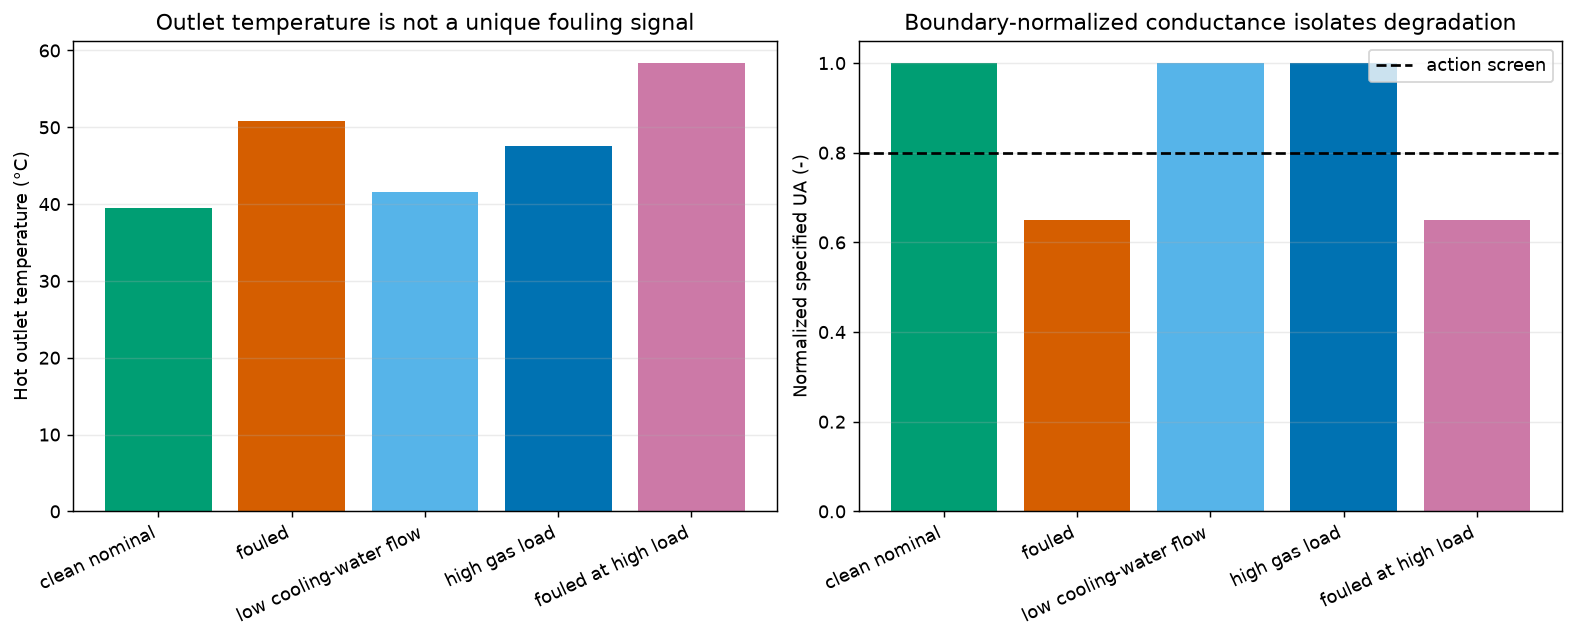

In [18]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.8),
    constrained_layout=True,
)
scenario_positions = np.arange(len(scenario_table))

axes[0].bar(
    scenario_positions,
    scenario_table["hot_out_c"],
    color=["#009E73", "#D55E00", "#56B4E9", "#0072B2", "#CC79A7"],
)
axes[0].set_xticks(
    scenario_positions,
    scenario_table["scenario"],
    rotation=25,
    ha="right",
)
axes[0].set_ylabel("Hot outlet temperature (°C)")
axes[0].set_title("Outlet temperature is not a unique fouling signal")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    scenario_positions,
    scenario_table["ua_w_k"] / CLEAN_UA_W_K,
    color=["#009E73", "#D55E00", "#56B4E9", "#0072B2", "#CC79A7"],
)
axes[1].set_xticks(
    scenario_positions,
    scenario_table["scenario"],
    rotation=25,
    ha="right",
)
axes[1].axhline(0.80, color="black", linestyle="--", label="action screen")
axes[1].set_ylabel("Normalized specified UA (-)")
axes[1].set_title("Boundary-normalized conductance isolates degradation")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()
plt.show()

## 16. Final application: reusable health snapshot

The function below accepts one complete operating record, runs NeqSim, infers conductance,
audits both measured duties, and returns a machine-readable decision snapshot. It can be placed
behind a historian, dashboard, or scheduled engineering calculation.

In [19]:
def evaluate_health_record(record, clean_reference_ua_w_k):
    hot_duty_w, cold_duty_w, imbalance_percent = outlet_enthalpy_duties(
        record["gas_flow_kg_h"],
        record["water_flow_kg_h"],
        record["gas_inlet_c"],
        record["water_inlet_c"],
        record["measured_hot_out_c"],
        record["measured_cold_out_c"],
    )
    estimated_ua_w_k = infer_ua_from_hot_outlet(
        measured_hot_out_c=record["measured_hot_out_c"],
        gas_flow_kg_h=record["gas_flow_kg_h"],
        water_flow_kg_h=record["water_flow_kg_h"],
        gas_inlet_c=record["gas_inlet_c"],
        water_inlet_c=record["water_inlet_c"],
    )
    ua_health_fraction = estimated_ua_w_k / clean_reference_ua_w_k
    fouling_resistance_m2_k_w = EXCHANGER_AREA_M2 * (
        1.0 / estimated_ua_w_k
        - 1.0 / clean_reference_ua_w_k
    )
    return {
        "estimated_ua_kw_k": estimated_ua_w_k / 1000.0,
        "ua_health_fraction": ua_health_fraction,
        "effective_fouling_m2_k_w": fouling_resistance_m2_k_w,
        "hot_duty_mw": hot_duty_w / 1.0e6,
        "cold_duty_mw": cold_duty_w / 1.0e6,
        "energy_imbalance_percent": imbalance_percent,
        "health_state": classify_health(
            ua_health_fraction,
            imbalance_percent,
        ),
    }


application_record = historian.loc[historian["day"] == 15.0].iloc[0]
application_snapshot = evaluate_health_record(
    application_record,
    clean_reference_ua_w_k,
)
display(pd.Series(application_snapshot, name="Day 15 snapshot").to_frame())

,Day 15 snapshot
estimated_ua_kw_k,37.910552
ua_health_fraction,0.784818
effective_fouling_m2_k_w,0.000681
hot_duty_mw,1.780442
cold_duty_mw,1.776688
energy_imbalance_percent,0.211068
health_state,action: degraded


## 17. Validation and engineering acceptance checks

The final gate checks numerical finiteness, monotonic model behavior, energy conservation,
inference accuracy on balance-qualified records, correct detection of the inserted sensor fault,
and recovery after cleaning.

In [20]:
valid_rows = historian["energy_imbalance_percent"] <= 3.0
ua_relative_error = abs(
    historian.loc[valid_rows, "estimated_ua_w_k"]
    - historian.loc[valid_rows, "true_ua_w_k"]
) / historian.loc[valid_rows, "true_ua_w_k"]

ua_sensitivity = [
    run_exchanger_case(ua_w_k)["hot_out_c"]
    for ua_w_k in (25_000.0, 35_000.0, 50_000.0, 65_000.0)
]

engineering_checks = {
    "all historian outputs finite": bool(
        np.isfinite(
            historian[
                [
                    "measured_hot_out_c",
                    "measured_cold_out_c",
                    "estimated_ua_w_k",
                    "energy_imbalance_percent",
                ]
            ].to_numpy()
        ).all()
    ),
    "hot outlet decreases with UA": bool(
        np.all(np.diff(ua_sensitivity) < 0.0)
    ),
    "base energy residual below 1e-7": (
        base_case["energy_residual_fraction"] < 1.0e-7
    ),
    "median qualified UA error below 1 percent": (
        float(ua_relative_error.median()) < 0.01
    ),
    "maximum qualified UA error below 2 percent": (
        float(ua_relative_error.max()) < 0.02
    ),
    "inserted sensor bias detected": (
        historian.loc[
            historian["day"] == 10.0,
            "health_state",
        ].iloc[0]
        == "data-quality alert"
    ),
    "degradation reaches action state": bool(
        (historian["health_state"] == "action: degraded").any()
    ),
    "cleaning restores healthy state": (
        historian.loc[
            historian["day"] == 16.0,
            "health_state",
        ].iloc[0]
        == "healthy"
    ),
    "scenario duties positive": bool(
        (scenario_table["duty_mw"] > 0.0).all()
    ),
    "scenario approaches positive": bool(
        (scenario_table["minimum_approach_c"] > 0.0).all()
    ),
}

display(pd.Series(engineering_checks, name="Passed").to_frame())
assert all(engineering_checks.values())

print(
    "Median qualified UA error: "
    f"{100.0 * ua_relative_error.median():.4f}%"
)
print(
    "Maximum qualified UA error: "
    f"{100.0 * ua_relative_error.max():.4f}%"
)
print(f"Engineering checks passed: {sum(engineering_checks.values())}")

Median qualified UA error: 0.2810%
Maximum qualified UA error: 0.3923%
Engineering checks passed: 10


,Passed
all historian outputs finite,True
hot outlet decreases with UA,True
base energy residual below 1e-7,True
median qualified UA error below 1 percent,True
maximum qualified UA error below 2 percent,True
inserted sensor bias detected,True
degradation reaches action state,True
cleaning restores healthy state,True
scenario duties positive,True
scenario approaches positive,True


## Troubleshooting

- **No bounded UA solution:** widen the bracket only after checking units, sensor validity, flow
  direction, and whether the exchanger is near a temperature cross.
- **Large hot/cold duty mismatch:** check flowmeter basis, temperature sensor bias, pressure,
  composition, heat loss, and phase change before estimating fouling.
- **Unexpected UA steps:** verify operating mode, bypass position, utility routing, and data
  timestamps.
- **Slow execution:** reduce monitoring frequency or cache a validated surrogate, but periodically
  compare it with the full NeqSim calculation.
- **Two-phase service:** include measured pressure drop and phase-aware validation; this simple
  steady-state screen is not a substitute for a detailed rating model.

## Summary and practical interpretation

- Native NeqSim stream and `HeatExchanger` objects normalize performance for actual boundaries.
- Hot/cold enthalpy closure provides a separate data-quality gate.
- Effective $UA$ tracks fouling and responds to cleaning more clearly than outlet temperature.
- A reusable record evaluator returns conductance, fouling resistance, balance residual, and
  health classification.

Use the result as a screening and investigation trigger. Maintenance decisions should combine
process evidence with inspection history, pressure drop, utility performance, and equipment risk.

## Further exercises

1. Add pressure-drop measurements and distinguish thermal fouling from hydraulic restriction.
2. Replace the deterministic noise with instrument uncertainty and propagate confidence limits.
3. Fit separate clean references for seasonal cooling-water temperatures.
4. Add a rate-of-change alert and estimate the next threshold-crossing date.
5. Connect the health snapshot to a process automation or online-simulation workflow.
6. Extend the model to condensing gas or a multi-stream exchanger.

## References

- [NeqSim heat-exchanger equipment](https://equinor.github.io/neqsim/process/equipment/heat_exchangers)
- [NeqSim process simulation package](https://equinor.github.io/neqsim/process/README.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [NeqSim heat-transfer modelling](https://equinor.github.io/neqsim/fluidmechanics/heat_transfer)
- Incropera, DeWitt, Bergman, and Lavine, *Fundamentals of Heat and Mass Transfer*.

The NeqSim documentation describes additional sizing and design capabilities that may be newer
than the tested PyPI release. This notebook uses only APIs exercised successfully with the version
printed during execution.